Iris Flower Classification — Predictive Modeling
**Task 2 | Data Science Internship**  
**Dataset:** Iris (sklearn built-in) | **Algorithm:** Logistic Regression, Decision Tree, Random Forest  
**Goal:** Predict iris flower species from petal & sepal measurements


In [15]:
# All these come pre-installed in Google Colab — no pip needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)

print("All libraries imported successfully!")


All libraries imported successfully!


## 1. Load & Explore the Dataset

In [14]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f"Shape     : {df.shape}")
print(f"Features  : {list(iris.feature_names)}")
print(f"Classes   : {list(iris.target_names)}")
df.head()


Shape     : (150, 5)
Features  : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes   : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [16]:
# Basic statistics
df.describe().round(2)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [17]:
# Check missing values and class distribution
print("Missing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['species'].value_counts())


Missing Values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Class Distribution:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 2. Exploratory Visualizations

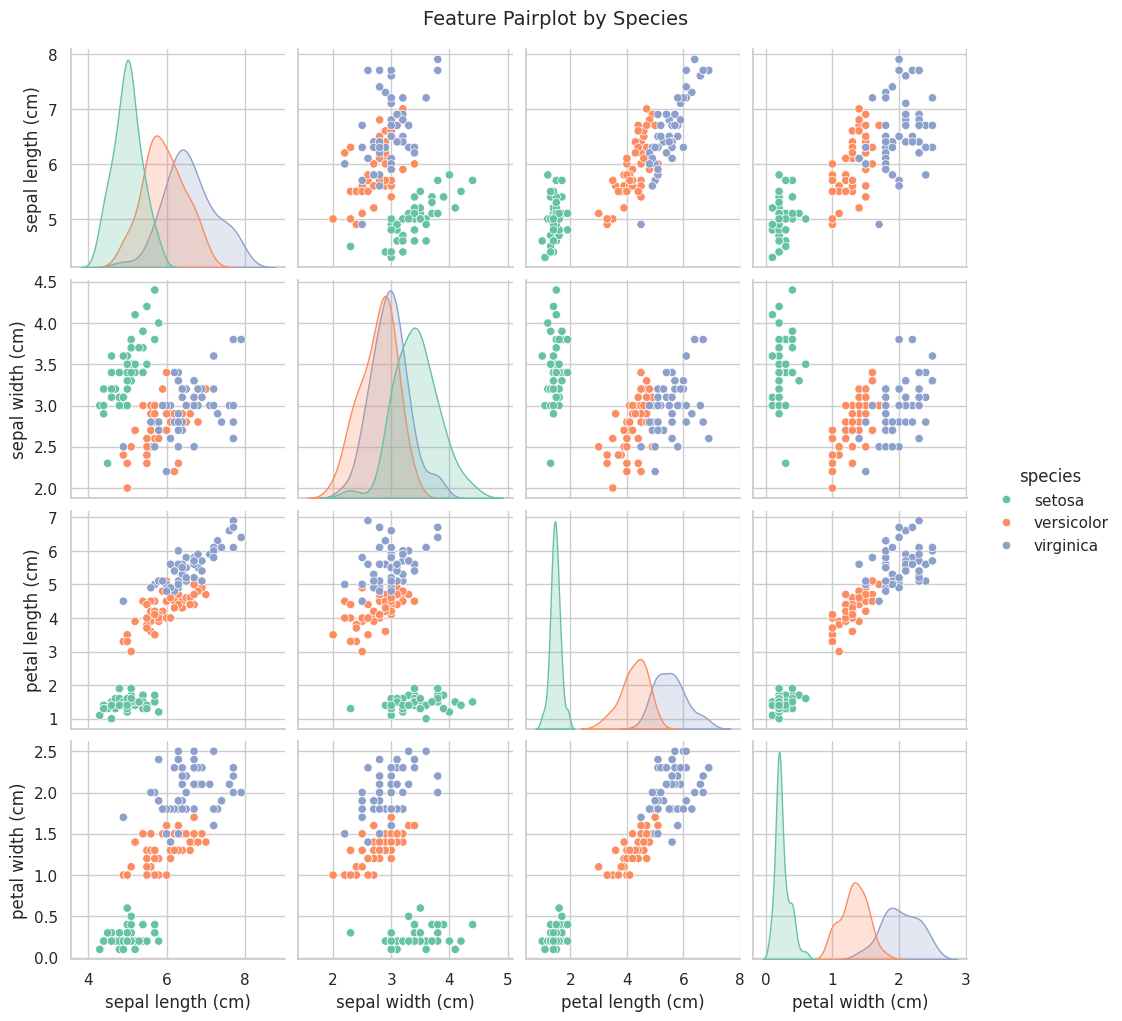

In [5]:
# Pairplot — see how features separate across species
sns.set_theme(style="whitegrid", palette="Set2")
pair = sns.pairplot(df, hue="species", diag_kind="kde", height=2.5)
pair.figure.suptitle("Feature Pairplot by Species", y=1.02, fontsize=14)
plt.show()


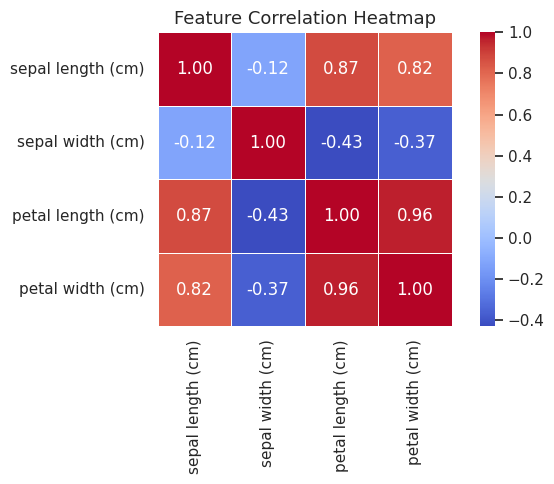

In [6]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = df.drop(columns='species').corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True)
plt.title("Feature Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.show()


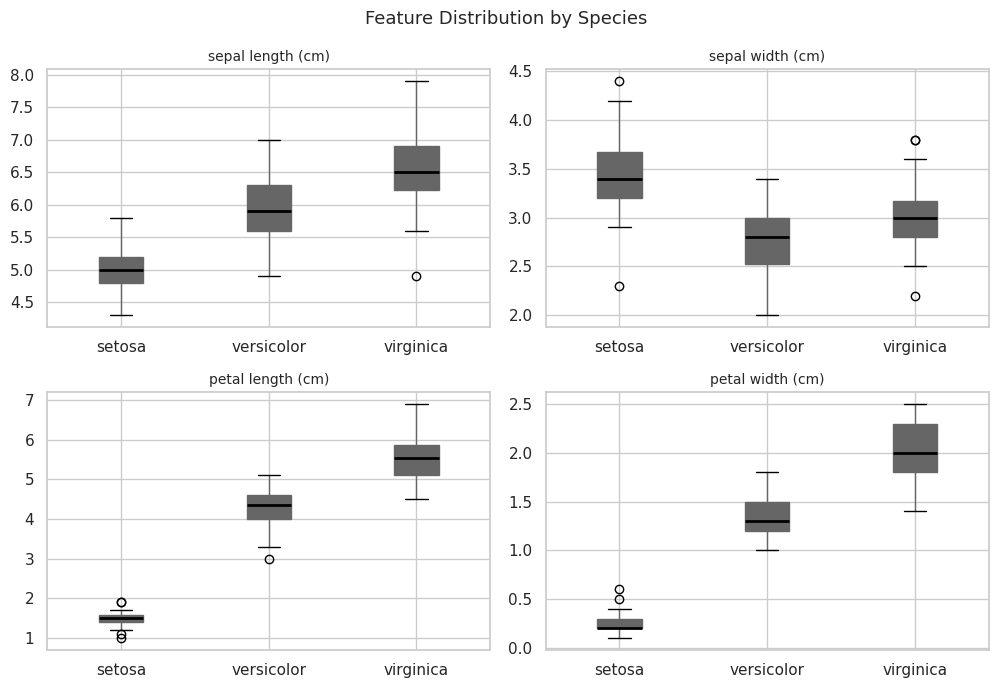

In [7]:
# Boxplots — feature spread per species
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()
for i, feat in enumerate(iris.feature_names):
    df.boxplot(column=feat, by='species', ax=axes[i],
               patch_artist=True,
               medianprops=dict(color="black", linewidth=2))
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel("")
fig.suptitle("Feature Distribution by Species", fontsize=13)
plt.tight_layout()
plt.show()


## 3. Data Preprocessing

In [8]:
X = df.drop(columns='species')
y = iris.target  # 0=setosa, 1=versicolor, 2=virginica

# 75% train, 25% test — stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")


Train size : 112 samples
Test size  : 38 samples


## 4. Model Training & Cross-Validation

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
print(f"{'Model':<25} {'CV Accuracy':>12} {'Test Accuracy':>14}")
print("-" * 55)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy')
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    test_acc = accuracy_score(y_test, y_pred)
    results[name] = {
        "model": model, "y_pred": y_pred,
        "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std(),
        "test_acc": test_acc
    }
    print(f"{name:<25} {cv_scores.mean():.4f} ± {cv_scores.std():.4f}    {test_acc:.4f}")


Model                      CV Accuracy  Test Accuracy
-------------------------------------------------------
Logistic Regression       0.9640 ± 0.0339    0.9211
Decision Tree             0.9292 ± 0.0444    0.9211
Random Forest             0.9375 ± 0.0360    0.9211


## 5. Confusion Matrices

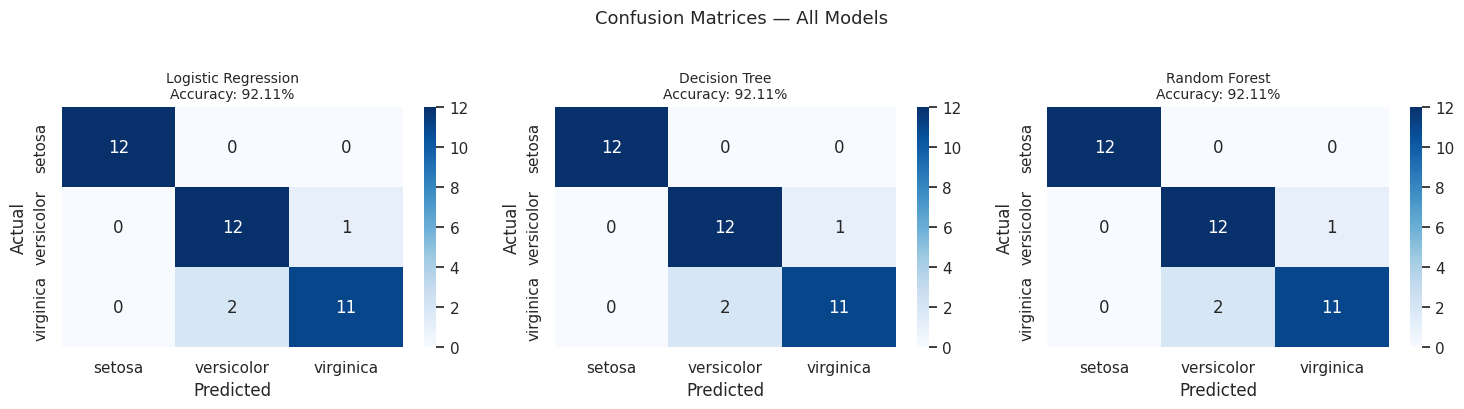

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=iris.target_names,
                yticklabels=iris.target_names)
    ax.set_title(f"{name}\nAccuracy: {res['test_acc']:.2%}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices — All Models", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 6. ROC Curves (One-vs-Rest)

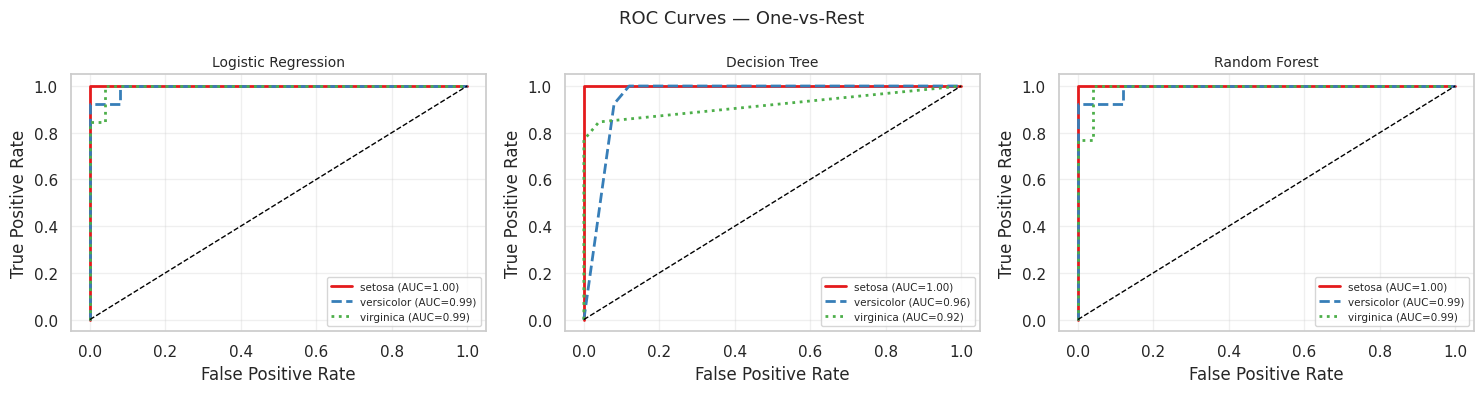

In [11]:
y_test_bin  = label_binarize(y_test, classes=[0, 1, 2])
colors_roc  = ["#e41a1c", "#377eb8", "#4daf4a"]
line_styles = ['-', '--', ':']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    y_score = res["model"].predict_proba(X_test_sc)
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc = roc_auc_score(y_test_bin[:, i], y_score[:, i])
        ax.plot(fpr, tpr, label=f"{iris.target_names[i]} (AUC={auc:.2f})",
                color=colors_roc[i], linestyle=line_styles[i], linewidth=2)
    ax.plot([0,1],[0,1], 'k--', linewidth=1)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=7.5)
    ax.grid(alpha=0.3)
plt.suptitle("ROC Curves — One-vs-Rest", fontsize=13)
plt.tight_layout()
plt.show()


## 7. Feature Importance (Random Forest)

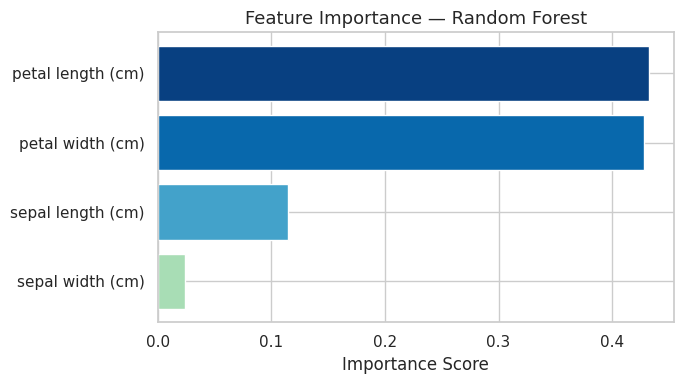

In [12]:
rf_model = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=iris.feature_names)
importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(importances_sorted.index, importances_sorted.values,
         color=["#a8ddb5","#43a2ca","#0868ac","#084081"])
plt.xlabel("Importance Score")
plt.title("Feature Importance — Random Forest", fontsize=13)
plt.tight_layout()
plt.show()


## 8. Final Classification Report

In [13]:
best_name = max(results, key=lambda k: results[k]["test_acc"])
best = results[best_name]

print("=" * 55)
print(f"  Best Model  : {best_name}")
print(f"  Test Acc    : {best['test_acc']:.4f}")
print(f"  CV Accuracy : {best['cv_mean']:.4f} ± {best['cv_std']:.4f}")
print("=" * 55)
print(classification_report(y_test, best["y_pred"],
                             target_names=iris.target_names))


  Best Model  : Logistic Regression
  Test Acc    : 0.9211
  CV Accuracy : 0.9640 ± 0.0339
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38

